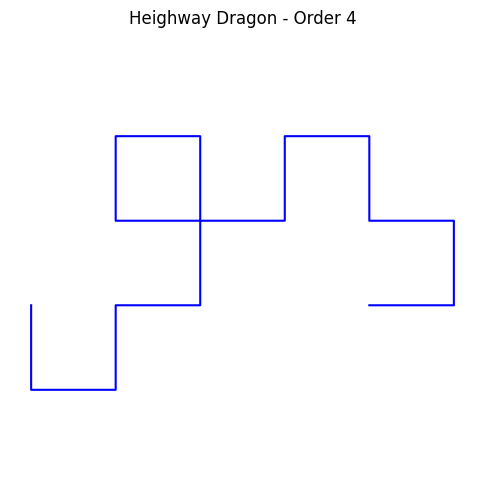

In [1]:
import matplotlib.pyplot as plt

def heighway_dragon(order=4, step=10):
    axiom = "FX"
    rules = {
        "X": "X+YF+",
        "Y": "-FX-Y"
    }

    # Expand the L-system
    seq = axiom
    for _ in range(order):
        seq = "".join(rules.get(ch, ch) for ch in seq)

    # Turtle interpretation
    x, y = 0, 0
    heading = 0  # in degrees: 0 = east
    pts = [(x, y)]

    for ch in seq:
        if ch == "F":
            # Move forward
            rad = heading * 3.14159 / 180
            x += step * round(cos(rad), 6)
            y += step * round(sin(rad), 6)
            pts.append((x, y))
        elif ch == "+":
            heading += 90
        elif ch == "-":
            heading -= 90

    return zip(*pts)

# Import trig functions
from math import cos, sin

# Generate coordinates for order 4
xs, ys = heighway_dragon(order=4, step=10)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(xs, ys, color="blue")
plt.axis("equal")
plt.axis("off")
plt.title("Heighway Dragon - Order 4")
plt.show()


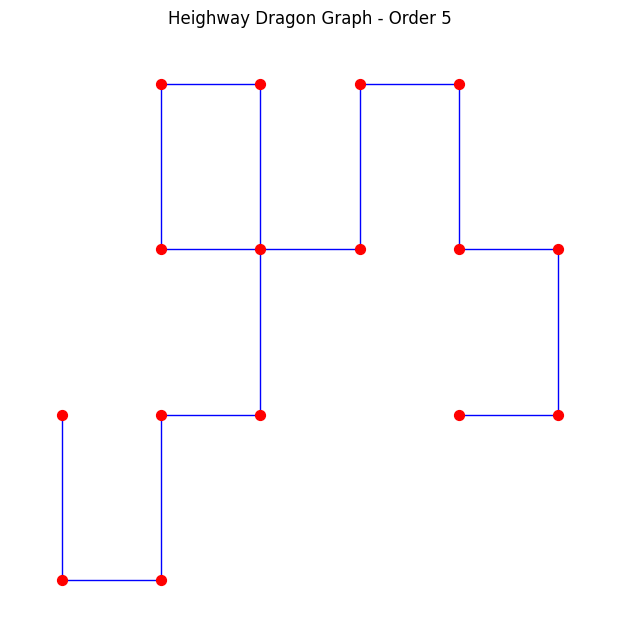

Vertices: 16, Edges: 16


In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from math import cos, sin, radians

def heighway_dragon_graph(order=5, step=1):
    # L-system
    axiom = "FX"
    rules = {
        "X": "X+YF+",
        "Y": "-FX-Y"
    }

    # Expand L-system
    seq = axiom
    for _ in range(order):
        seq = "".join(rules.get(ch, ch) for ch in seq)

    # Build graph
    G = nx.Graph()
    x, y = 0, 0
    heading = 0
    prev = (x, y)
    G.add_node(prev)

    for ch in seq:
        if ch == "F":
            rad = radians(heading)
            x += step * cos(rad)
            y += step * sin(rad)
            curr = (round(x, 6), round(y, 6))  # round to avoid float precision issues
            G.add_node(curr)
            G.add_edge(prev, curr)
            prev = curr
        elif ch == "+":
            heading += 90
        elif ch == "-":
            heading -= 90
        # ignore X, Y

    return G

# Generate graph for order 4
G = heighway_dragon_graph(order=4, step=10)

# Draw graph
plt.figure(figsize=(6, 6))
pos = {node: node for node in G.nodes()}  # use actual coordinates
nx.draw(G, pos, node_size=50, node_color="red", edge_color="blue", with_labels=False)
plt.title("Heighway Dragon Graph - Order 5")
plt.show()

print(f"Vertices: {len(G.nodes())}, Edges: {len(G.edges())}")


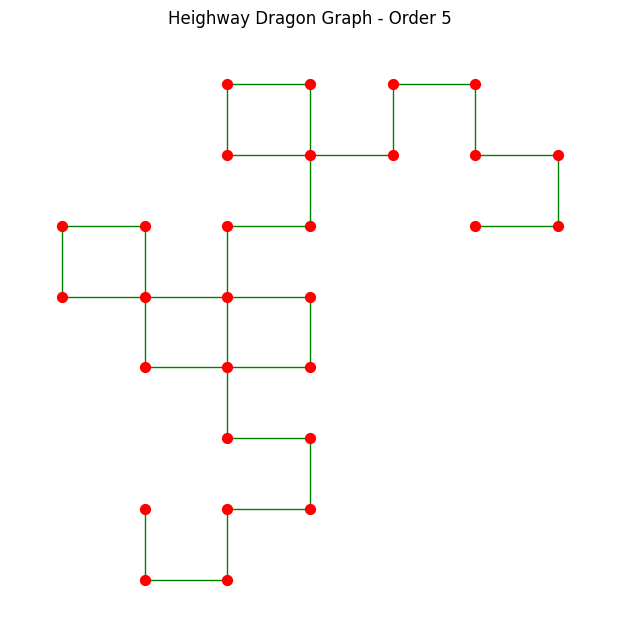

Vertices: 29, Edges: 32


In [4]:
import matplotlib.pyplot as plt
import networkx as nx
from math import cos, sin, radians

def heighway_dragon_graph(order=5, step=1):
    # L-system
    axiom = "FX"
    rules = {
        "X": "X+YF+",
        "Y": "-FX-Y"
    }

    # Expand L-system
    seq = axiom
    for _ in range(order):
        seq = "".join(rules.get(ch, ch) for ch in seq)

    # Build graph
    G = nx.Graph()
    x, y = 0, 0
    heading = 0
    prev = (x, y)
    G.add_node(prev)

    for ch in seq:
        if ch == "F":
            rad = radians(heading)
            x += step * cos(rad)
            y += step * sin(rad)
            curr = (round(x, 6), round(y, 6))  # round to avoid float precision issues
            G.add_node(curr)
            G.add_edge(prev, curr)
            prev = curr
        elif ch == "+":
            heading += 90
        elif ch == "-":
            heading -= 90
        # ignore X, Y

    return G

# Generate graph for order 5
G = heighway_dragon_graph(order=5, step=10)

# Draw graph
plt.figure(figsize=(6, 6))
pos = {node: node for node in G.nodes()}  # use actual coordinates
nx.draw(G, pos, node_size=50, node_color="red", edge_color="green", with_labels=False)
plt.title("Heighway Dragon Graph - Order 5")
plt.show()

print(f"Vertices: {len(G.nodes())}, Edges: {len(G.edges())}")


In [6]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 26.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.31.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21

Graceful labeling found!
(0, 0): 0
(10.0, 0.0): 16
(10.0, 10.0): 1
(0.0, 10.0): 15
(0.0, 20.0): 2
(-10.0, 20.0): 14
(-10.0, 10.0): 3
(-20.0, 10.0): 13
(-20.0, 20.0): 5
(-30.0, 20.0): 12
(-30.0, 10.0): 7
(-20.0, -0.0): 4
(-30.0, -0.0): 8
(-30.0, -10.0): 11
(-40.0, -10.0): 9
(-40.0, 0.0): 10


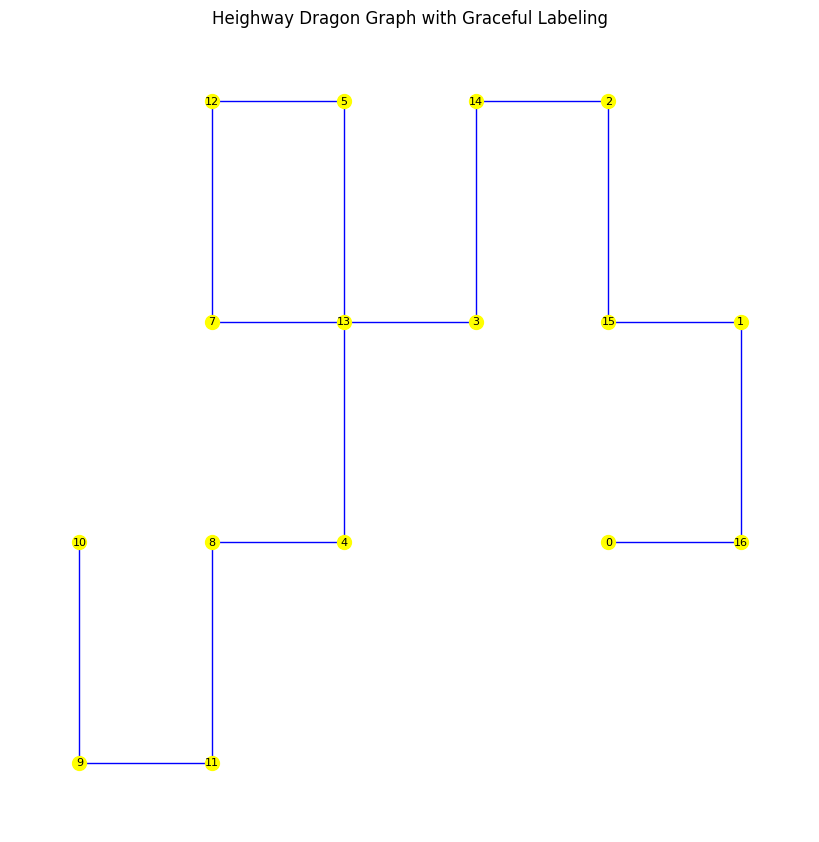

In [8]:
import matplotlib.pyplot as plt
import networkx as nx
from math import cos, sin, radians
from ortools.sat.python import cp_model

# --- Heighway Dragon Graph ---
def heighway_dragon_graph(order=4, step=1):
    axiom = "FX"
    rules = {"X": "X+YF+", "Y": "-FX-Y"}
    seq = axiom
    for _ in range(order):
        seq = "".join(rules.get(ch, ch) for ch in seq)

    G = nx.Graph()
    x, y = 0, 0
    heading = 0
    prev = (x, y)
    G.add_node(prev)

    for ch in seq:
        if ch == "F":
            rad = radians(heading)
            x += step * cos(rad)
            y += step * sin(rad)
            curr = (round(x, 6), round(y, 6))
            G.add_node(curr)
            G.add_edge(prev, curr)
            prev = curr
        elif ch == "+":
            heading += 90
        elif ch == "-":
            heading -= 90
    return G

# --- Graceful Labeling ---
def graceful_labeling(G):
    model = cp_model.CpModel()
    nodes = list(G.nodes())
    q = G.number_of_edges()

    # Vertex labels
    vertex_labels = {v: model.NewIntVar(0, q, f"v_{i}") for i, v in enumerate(nodes)}
    model.AddAllDifferent(vertex_labels.values())

    # Edge labels
    edge_labels = []
    for i, (u, v) in enumerate(G.edges()):
        e = model.NewIntVar(1, q, f"e_{i}")
        model.AddAbsEquality(e, vertex_labels[u] - vertex_labels[v])
        edge_labels.append(e)

    model.AddAllDifferent(edge_labels)

    # Solve
    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        return {v: solver.Value(var) for v, var in vertex_labels.items()}
    else:
        print("No graceful labeling found.")
        return None

# --- Generate Graph ---
G = heighway_dragon_graph(order=4, step=10)  # Order 4 recommended

# --- Compute Graceful Labeling ---
labels = graceful_labeling(G)

if labels:
    print("Graceful labeling found!")
    for node, label in labels.items():
        print(f"{node}: {label}")

    # --- Draw Graph ---
    plt.figure(figsize=(8, 8))
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, node_color='yellow', node_size=100, with_labels=False, edge_color='blue')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title("Heighway Dragon Graph with Graceful Labeling")
    plt.show()
else:
    print("Graceful labeling could not be computed.")


Graceful labeling found!
(0, 0): 36
(10.0, 0.0): 28
(10.0, 10.0): 45
(0.0, 10.0): 19
(0.0, 20.0): 47
(-10.0, 20.0): 35
(-10.0, 10.0): 20
(-20.0, 10.0): 9
(-20.0, 20.0): 51
(-30.0, 20.0): 13
(-30.0, 10.0): 49
(-20.0, -0.0): 12
(-30.0, -0.0): 55
(-30.0, -10.0): 2
(-40.0, -10.0): 63
(-40.0, 0.0): 15
(-50.0, 0.0): 38
(-50.0, -10.0): 8
(-40.0, -20.0): 4
(-30.0, -20.0): 64
(-20.0, -10.0): 58
(-20.0, -20.0): 1
(-30.0, -30.0): 0
(-20.0, -30.0): 41
(-20.0, -40.0): 39
(-30.0, -40.0): 26
(-30.0, -50.0): 16
(-40.0, -50.0): 25
(-40.0, -40.0): 44
(-50.0, -40.0): 24
(-50.0, -50.0): 46
(-40.0, -60.0): 21
(-30.0, -60.0): 60
(-20.0, -50.0): 53
(-20.0, -60.0): 18
(-10.0, -60.0): 52
(-10.0, -50.0): 7
(-10.0, -40.0): 6
(-10.0, -30.0): 33
(-0.0, -30.0): 40
(-0.0, -40.0): 56
(-0.0, -50.0): 59
(-0.0, -60.0): 27
(10.0, -60.0): 3
(10.0, -50.0): 61
(20.0, -50.0): 10
(20.0, -60.0): 57
(10.0, -70.0): 34
(20.0, -70.0): 5
(20.0, -80.0): 54
(10.0, -80.0): 29
(10.0, -90.0): 11
(-0.0, -90.0): 17
(-0.0, -80.0): 22


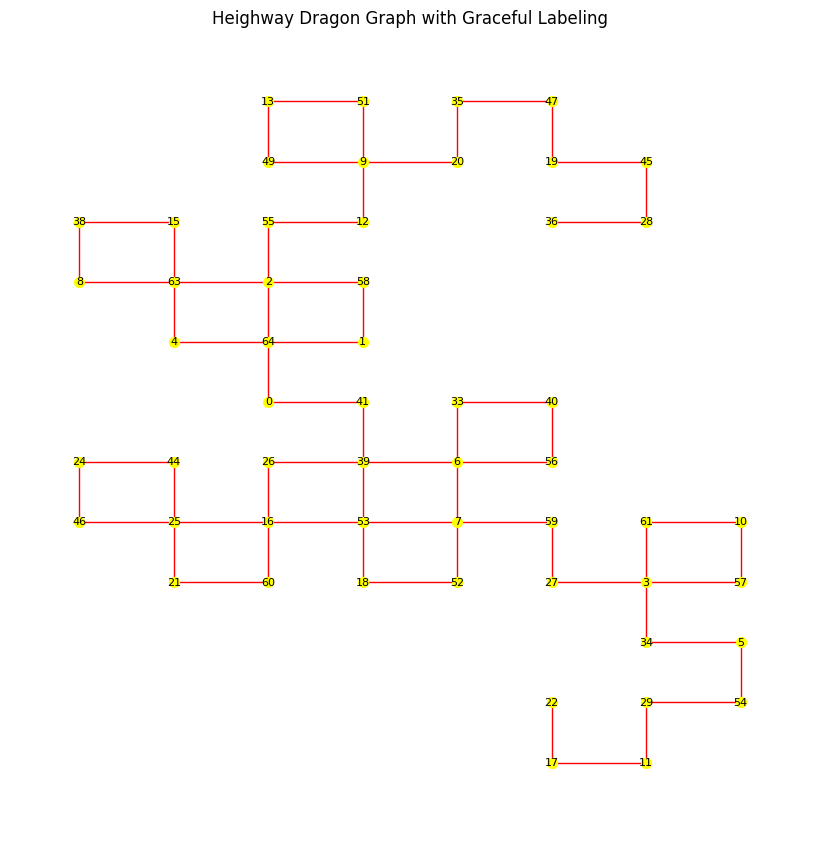

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
from math import cos, sin, radians
from ortools.sat.python import cp_model

# --- Heighway Dragon Graph ---
def heighway_dragon_graph(order=4, step=1):
    axiom = "FX"
    rules = {"X": "X+YF+", "Y": "-FX-Y"}
    seq = axiom
    for _ in range(order):
        seq = "".join(rules.get(ch, ch) for ch in seq)

    G = nx.Graph()
    x, y = 0, 0
    heading = 0
    prev = (x, y)
    G.add_node(prev)

    for ch in seq:
        if ch == "F":
            rad = radians(heading)
            x += step * cos(rad)
            y += step * sin(rad)
            curr = (round(x, 6), round(y, 6))
            G.add_node(curr)
            G.add_edge(prev, curr)
            prev = curr
        elif ch == "+":
            heading += 90
        elif ch == "-":
            heading -= 90
    return G

# --- Graceful Labeling ---
def graceful_labeling(G):
    model = cp_model.CpModel()
    nodes = list(G.nodes())
    q = G.number_of_edges()

    # Vertex labels
    vertex_labels = {v: model.NewIntVar(0, q, f"v_{i}") for i, v in enumerate(nodes)}
    model.AddAllDifferent(vertex_labels.values())

    # Edge labels
    edge_labels = []
    for i, (u, v) in enumerate(G.edges()):
        e = model.NewIntVar(1, q, f"e_{i}")
        model.AddAbsEquality(e, vertex_labels[u] - vertex_labels[v])
        edge_labels.append(e)

    model.AddAllDifferent(edge_labels)

    # Solve
    solver = cp_model.CpSolver()
    status = solver.Solve(model)

    if status in [cp_model.OPTIMAL, cp_model.FEASIBLE]:
        return {v: solver.Value(var) for v, var in vertex_labels.items()}
    else:
        print("No graceful labeling found.")
        return None

# --- Generate Graph ---
G = heighway_dragon_graph(order=6, step=10)  # Order 4 recommended

# --- Compute Graceful Labeling ---
labels = graceful_labeling(G)

if labels:
    print("Graceful labeling found!")
    for node, label in labels.items():
        print(f"{node}: {label}")

    # --- Draw Graph ---
    plt.figure(figsize=(8, 8))
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, node_color='yellow', node_size=50, with_labels=False, edge_color='red')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    plt.title("Heighway Dragon Graph with Graceful Labeling")
    plt.show()
else:
    print("Graceful labeling could not be computed.")
